<a href="https://colab.research.google.com/github/DrFaus/Estadistica2026B/blob/main/SeriesDeTiempo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Series de tiempo

Una serie de tiempo es un conjunto de observaciones de una variable registradas en distintos momentos del tiempo. A diferencia de otros tipos de datos, en una serie de tiempo el orden temporal es FUNDAMENTAL, ya que cada observación puede estar relacionada con valores pasados.

Por ejemplo, son series de tiempo:

+ Las ventas mensuales de una empresa
+ La temperatura registrada cada día
+ El número de pacientes atendidos por semana

En todos estos casos, el interés no sólo está en los valores observados, sino en cómo evolucionan a lo largo del tiempo.

En contraste, no es una serie de tiempo cualquier conjunto de datos donde el tiempo no juega un papel relevante en el análisis. Por ejemplo:

+ La relación entre estatura y peso de un grupo de personas
+ El ingreso mensual y el gasto de distintos individuos en un mismo periodo
+ La relación entre horas de estudio y calificación

En estos casos, las observaciones pueden analizarse sin considerar un orden temporal, ya que el interés principal está en la relación entre variables, no en su evolución.

El análisis de series de tiempo es adecuado cuando:

+ Los datos están organizados cronológicamente
+ Existe interés en identificar patrones en el tiempo (tendencias, estacionalidad, ciclos, lo veremos más adelante)
+ Se desea realizar pronósticos basados en el comportamiento pasado

Por ejemplo, si una empresa quiere prever sus ventas futuras con base en datos históricos, el enfoque de series de tiempo es el más adecuado.

En cambio, el análisis mediante correlación o regresión lineal es más apropiado cuando:

+ Se desea estudiar la relación entre dos o más variables
+ El tiempo no es una variable relevante en el análisis
+ Las observaciones son independientes entre sí

Por ejemplo, analizar si existe relación entre el precio de un producto y su demanda en distintos mercados corresponde a un enfoque de regresión, no necesariamente de series de tiempo.

La diferencia principal radica en el rol del tiempo:

+ En una serie de tiempo, el tiempo es una variable esencial y el orden de los datos no puede alterarse.
+ En correlación o regresión, el orden de los datos es irrelevante, ya que el análisis se centra en la relación entre variables.

Comprender esta diferencia es fundamental para elegir correctamente la herramienta de análisis y evitar interpretaciones incorrectas.

## Componentes de una serie de tiempo

Al analizar una serie de tiempo, es común identificar ciertos patrones que explican su comportamiento. Estos patrones se conocen como componentes de la serie de tiempo y permiten comprender mejor la estructura de los datos. De aquí en adelante utilizaremos un ejemplo para realizar el análisis de la serie de tiempo.

Ejemplo: Una empresa dedicada a la fabricación y distribución de juguetes ha registrado sus ventas diarias durante dos años consecutivos en miles de pesos.

Primero importamos los datos de la misma manera que se ha hecho hasta ahora.



In [ ]:
import pandas as pd

link = "https://raw.githubusercontent.com/DrFaus/Estadistica2026B/refs/heads/main/SeriesTemporales/series_de_tiempo.csv"

df = pd.read_csv(link)

df.drop(columns="Unnamed: 0", inplace=True)  # Recordar que "Unnamed: 0" es una variable que por lo general se debe eliminar.

df

,fecha,tendencia,estacionalidad,ruido,ventas
0,2023-01-01,120.00,-20.647942,-10.856306,88.495752
1,2023-01-02,120.18,-20.564959,9.973454,109.588496
2,2023-01-03,120.36,-20.461173,2.829785,102.728612
3,2023-01-04,120.54,-20.336408,-15.062947,85.140645
4,2023-01-05,120.72,-20.190510,-5.786003,94.743488
...,...,...,...,...,...
726,2024-12-27,134.62,-20.776218,3.920780,117.764562
727,2024-12-28,134.62,-20.774204,7.473930,121.319726
728,2024-12-29,134.62,-20.752329,2.727347,116.595018
729,2024-12-30,134.62,-20.710324,4.253359,118.163034


Se utiliza el método `.info()` para conocer la cantidad de datos de cada variable y saber si hay datos faltantes, además del tipo de dato que contiene cada columna.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fecha           731 non-null    object 
 1   tendencia       731 non-null    float64
 2   estacionalidad  731 non-null    float64
 3   ruido           731 non-null    float64
 4   ventas          731 non-null    float64
dtypes: float64(4), object(1)
memory usage: 28.7+ KB


Vemos que la base de datos tiene 731 entradas así como 731 datos en cada variable. Hay congruencia, por lo que no es necesario usar el método `.dropna()`. Pero, la variable `fecha` tiene datos del tipo `object`. Esto no debe ocurrir en la serie de tiempo. Esto se corrige de la siguiente forma:

In [ ]:
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d')
# format='%Y-%m-%d' porque la variable fecha tiene datos en Año (%Y), mes (%m) y día (%d)
# Si vieramos en la variable "fecha" valores como "25-08-2023" entonces el argumento tendría que fijarse como:
# format='%d-%m-%Y'

df

,fecha,tendencia,estacionalidad,ruido,ventas
0,2023-01-01,120.00,-20.647942,-10.856306,88.495752
1,2023-01-02,120.18,-20.564959,9.973454,109.588496
2,2023-01-03,120.36,-20.461173,2.829785,102.728612
3,2023-01-04,120.54,-20.336408,-15.062947,85.140645
4,2023-01-05,120.72,-20.190510,-5.786003,94.743488
...,...,...,...,...,...
726,2024-12-27,134.62,-20.776218,3.920780,117.764562
727,2024-12-28,134.62,-20.774204,7.473930,121.319726
728,2024-12-29,134.62,-20.752329,2.727347,116.595018
729,2024-12-30,134.62,-20.710324,4.253359,118.163034


Aplicamos el método `.info()` nuevamente:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   fecha           731 non-null    datetime64[ns]
 1   tendencia       731 non-null    float64       
 2   estacionalidad  731 non-null    float64       
 3   ruido           731 non-null    float64       
 4   ventas          731 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 28.7 KB


Ahora la variable `fecha` tiene datos del timpo `datetime`. Esto es lo que debe de ocurrir. Entonces graficando la serie de tiempo, se obtiene:

In [ ]:
x = df["fecha"]
y = df["ventas"]

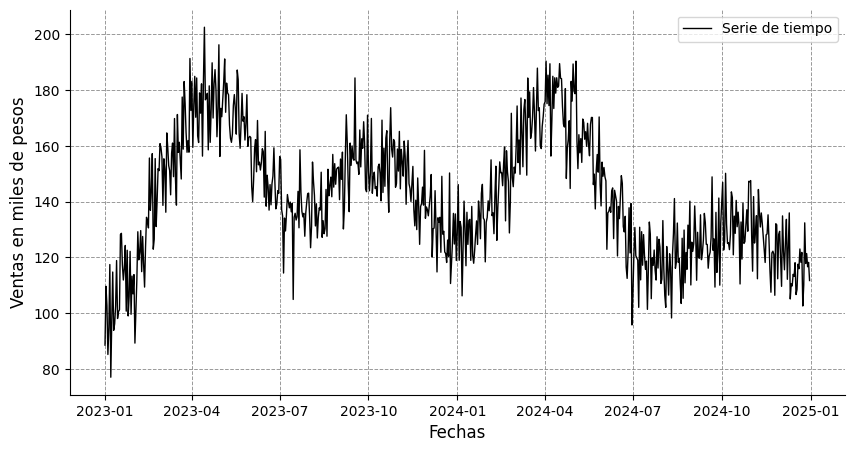

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Esta base de datos es de carácter sintético, es decir, fue generada mediante simulación computacional. Por esta razón, sus componentes han sido construidos de manera independiente, lo que permite distinguir claramente las variables `tendencia`, `estacionalidad` y `ruido`.

En situaciones reales, estos componentes no se observan por separado, sino que se encuentran combinados dentro de la variable ventas, por lo que su identificación directa no es posible.

A lo largo del análisis de series de tiempo, existen métodos que permiten estimar o aproximar estos componentes a partir de los datos observados. Sin embargo, para fines didácticos, en esta etapa se trabajará bajo el supuesto de que dichos componentes son conocidos, con el objetivo de facilitar la comprensión de su efecto en el comportamiento de la serie.

### Tendencia (Trend)

La tendencia representa la dirección general de la serie a lo largo del tiempo. Indica si los valores tienden a:

+ Incrementarse
+ Disminuir
+ Permanecer relativamente constantes

Por ejemplo, el crecimiento sostenido en las ventas de una empresa a lo largo de varios años refleja una tendencia positiva.



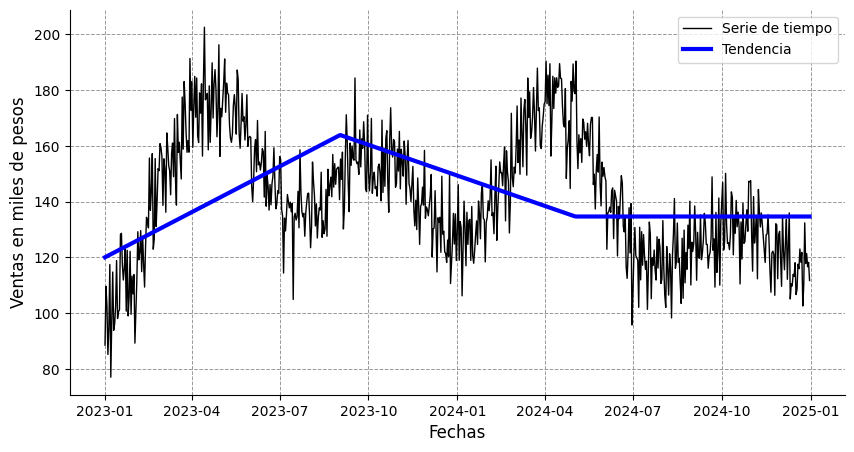

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df['tendencia'],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Si se observa únicamente la serie de tiempo, podría parecer que las ventas presentan un comportamiento aproximadamente estacionario, es decir, sin una tendencia clara de crecimiento o decrecimiento.

Sin embargo, una ventaja de esta base de datos sintética es que permite conocer la estructura "verdadera" de la serie. Tenemos el privilegio de desglosar las capas de la serie de tiempo como con rayos X y ver la tendencia verdadera. Al analizar el componente de tendencia, se identifica que, en un inicio, la empresa experimentó un crecimiento sostenido en sus ventas, el cual se mantuvo aproximadamente hasta el mes de septiembre de 2023 (2023-09).

Posteriormente, se observa un cambio en el comportamiento, caracterizado por una disminución en las ventas. Este descenso podría estar asociado a diversos factores, como decisiones corporativas, cambios en el mercado o eventos externos. Esta tendencia a la baja se prolonga hasta alrededor de mayo de 2024 (2024-05), momento en el cual la empresa logra estabilizar su nivel de ventas.

### Estacionalidad (Seasonal)

La estacionalidad corresponde a patrones que se repiten en intervalos regulares y conocidos dentro del tiempo, como:

+ Meses del año
+ Días de la semana
+ Estaciones

Por ejemplo:

+ Aumento en ventas durante diciembre
+ Mayor consumo de electricidad en verano

Estos patrones son predecibles y ocurren con una periodicidad fija.

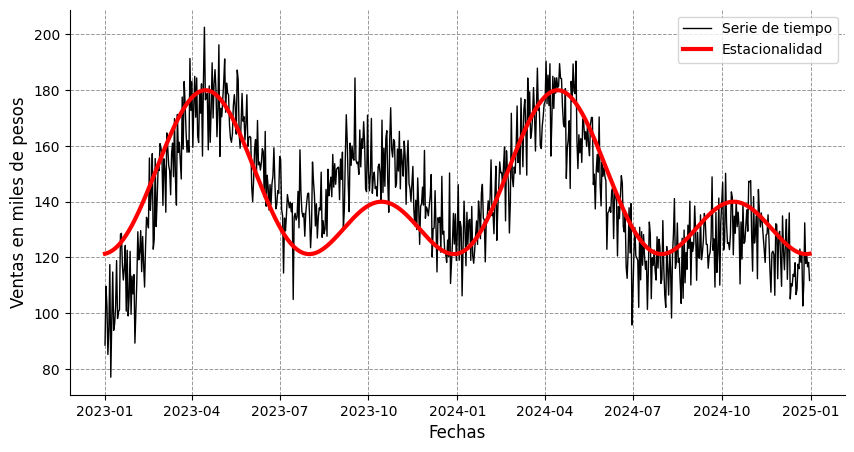

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["estacionalidad"] + df["tendencia"].mean(),
    color='red',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Estacionalidad'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



La estacionalidad, por su naturaleza, es un componente estacionario, ya que sus patrones se repiten de manera sistemática a lo largo del tiempo. En el ejemplo analizado, la serie de tiempo está fuertemente influenciada por la estacionalidad, lo que la convierte en el componente predominante en el comportamiento de las ventas.

Una característica fundamental de la estacionalidad es su carácter periódico. En el caso de una estacionalidad anual, la más común en contextos empresariales, el patrón observado tiende a repetirse cada año. Al analizar el gráfico, se aprecia que el comportamiento de las ventas en 2024 replica el observado en 2023; es decir, a partir de enero de 2024 se presenta una dinámica muy similar a la registrada desde enero de 2023.

En particular, se identifican puntos recurrentes de alta demanda: el máximo principal ocurre en abril, mientras que un segundo pico se presenta hacia el último trimestre del año.

Comprender la estacionalidad es fundamental para una correcta interpretación de la serie, ya que permite aislar sus efectos y evitar atribuirlos erróneamente a la tendencia u otros factores. Por ejemplo, si se implementa una decisión importante en mayo, es esperable observar una disminución en las ventas debido al patrón estacional, y no necesariamente como consecuencia de dicha decisión. De manera similar, si se toma una decisión en enero, el incremento posterior en las ventas podría estar explicado principalmente por la estacionalidad y no por el impacto real de la medida adoptada.

### Ruido o residuales (noise o residuals)

Este componente incluye las variaciones impredecibles o aleatorias de la serie.
Son causadas por factores no controlados o eventos inesperados, como:

+ Cambios abruptos en el mercado
+ Eventos externos (crisis, desastres, etc.)

O simplemente a la multiple combinación de factores que no se pueden medir.

Este componente no sigue un patrón definido y no puede modelarse directamente.

En este caso, parte del ruido podría explicarse por las familias que dejan de consumir juguetes porque sus hijos dejaron de ser niños. Estos cambios no se pueden medir ni cuantificar. También puede deberse a las estrategias de la competencia, un juguete de moda o al repentino interés/desinterés por comprar juguetes.

Veamos el como se ve el ruido en el gráfico.

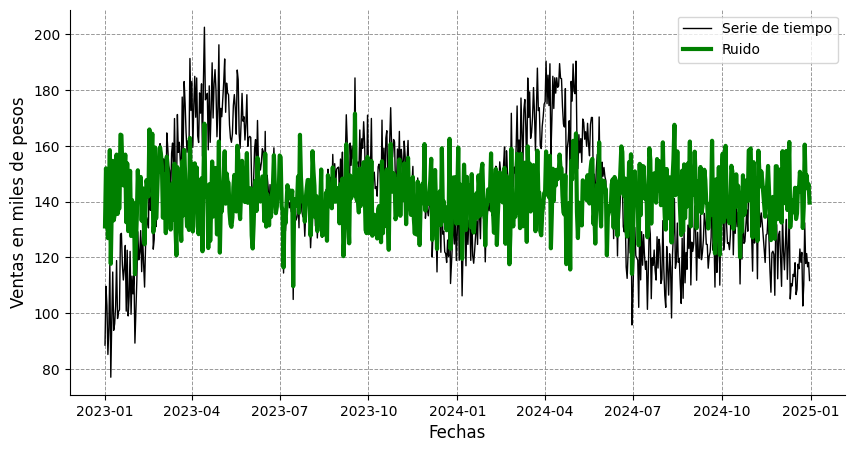

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["ruido"] + df["tendencia"].mean(),
    color='green',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Ruido'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



El ruido no tiene tendencia ni estacionalidad, es completamente aleatorio. La magnitud del ruido tiene que ser aproximadamente constante (homoscedasticidad) y no hay ningún patrón definido. Si algo de lo anterior no se cumple, entonces el ruido se llevó algo de tendencia o estacionalidad.

A continuación, abordaremos algunos métodos para obtener la tendencia.

## Método de mínimos cuadrados.

El método de mínimos cuadrados es, en esencia, un método de regresión. En el contexto de series de tiempo, este enfoque puede utilizarse para estimar la tendencia de la serie.

Si bien la forma más sencilla consiste en aplicar regresión lineal, es posible extender este concepto mediante el uso de regresión polinomial, lo que permite capturar comportamientos más complejos en la tendencia.

De esta manera, la regresión no sólo se limita a modelar relaciones entre variables, sino que también puede emplearse como una herramienta para identificar y aproximar la tendencia subyacente en una serie de tiempo.

Para este procedimiento, utilizamos el siguiente código.

In [ ]:
from numpy.polynomial.polynomial import Polynomial
X = pd.to_datetime(df["fecha"]).map(pd.Timestamp.timestamp)
grado = 3
modelo = Polynomial.fit(X, y, deg = grado)
df['tendencia_polinomial'] = modelo(X)
df['ruido_polinomial'] = y - df['tendencia_polinomial']

Primero, se obtiene un valor numérico de la fecha. Mediante `timestamp` transformamos la fecha a tiempo Unix (segundos transcurridos desde el 1 de enero de 1970, época Unix). Luego se selecciona el grado de la regresión. La regresión lineal se hace con `grado=1`. Una forma útil de seleccionar el grado, es determinar cuántas curvas queremos que el modelo sea capaz de expresar y sumarle 1. En este ejemplo, creemos que la tendencia muestra dos curvas, entonces es `grado=3`.

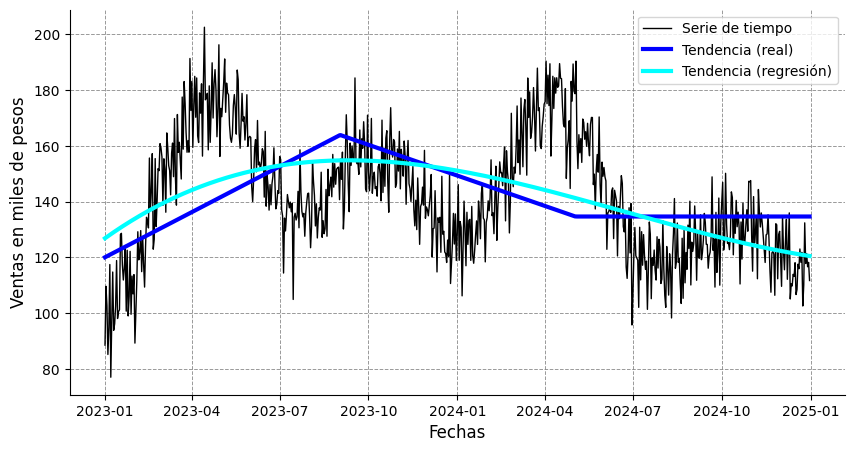

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia"],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (real)'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia_polinomial"],
    color='cyan',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (regresión)'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



No existe un criterio único y universal para seleccionar el grado del polinomio. En la práctica, esta elección depende en gran medida del criterio y la experiencia del analista, por lo que es recomendable probar distintos grados y evaluar cuál ofrece un ajuste adecuado.

Sin embargo, es importante tener en cuenta que al aumentar el grado del polinomio, el modelo puede comenzar a capturar no sólo la tendencia, sino también la estacionalidad e incluso el ruido. Esto puede llevar a una representación distorsionada del componente de interés.

Por ejemplo, si se utiliza un grado elevado, como `grado = 20`, el polinomio puede ajustarse muy bien a los datos observados, pero este ajuste incluirá variaciones que no corresponden a la tendencia, sino a otros componentes de la serie, como la estacionalidad.

## Métodos de promedios móviles

En este método, se calcula el promedio de los últimos $n$ valores de la serie. A medida que se incorporan nuevos datos, este promedio se actualiza de forma continua, lo que permite suavizar las fluctuaciones y resaltar el comportamiento general de la serie.

De esta manera, la media móvil actúa como un mecanismo de filtrado que atenúa la variabilidad de corto plazo, facilitando la identificación de la tendencia subyacente.

Hay dos métodos principales para la aplicación de los promedios moviles:



### Media móvil simple

SMA por sus siglas en inglés: _Simple Moving Average_. La media móvil simple consiste en calcular el promedio de los últimos $n$ valores de la serie. Cada observación dentro de la ventana tiene el mismo peso, por lo que el valor suavizado depende únicamente de los datos más recientes considerados.

Este método permite reducir la variabilidad de corto plazo y facilitar la identificación de la tendencia, aunque puede reaccionar con cierta lentitud ante cambios bruscos.

Una media movil puede calcularse con el método `.rolling()` ingresando el argumento `window` el cual establece cuántas unidades de tiempo tomará para calcular la media. Si se fija en `window=30` entonces cada punto representa el promedio de los 30 días anteriores (ya sabemos que la unidad de tiempo está en días). Como se muestra en el siguiente gráfico.

In [ ]:
# Promedio Móvil Simple
df['ventas_SMA'] = df['ventas'].rolling(window=30).mean()

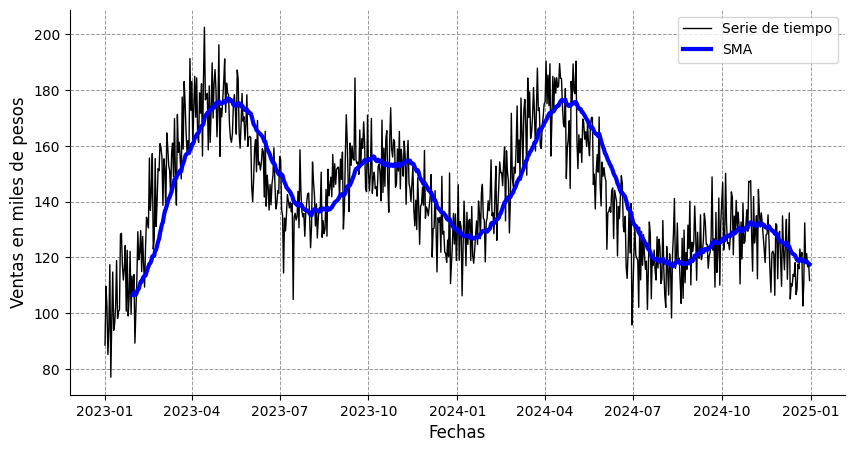

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["ventas_SMA"],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='SMA'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Al modificar el valor del argumento `window`, es posible controlar el grado de suavizamiento de la serie: valores pequeños generan una curva más reactiva, mientras que valores grandes producen una curva más estable.

No obstante, a medida que aumenta el tamaño de la ventana, la media móvil simple (SMA) se vuelve menos sensible a cambios bruscos en la serie, ya que cada nuevo dato tiene un impacto reducido en el promedio.

Para atender esta limitación, se utiliza la media móvil exponencial, también conocida como suavización exponencial, la cual asigna mayor peso a las observaciones más recientes, permitiendo una respuesta más rápida ante cambios en el comportamiento de la serie.

### Media móvil exponencial

SES por sus siglas en inglés: _Simple Exponential Smoothing_. La media móvil exponencial también busca suavizar la serie, pero a diferencia de la media móvil simple, asigna mayor peso a las observaciones más recientes y menor peso a las más antiguas.

Esto permite que el método sea más sensible a cambios recientes en los datos, adaptándose con mayor rapidez a nuevas tendencias, aunque manteniendo el efecto de suavizamiento.

Para el cálculo de SES se utiliza el método `.ewm()` que asigna los pesos a los $n$-simos valores seleccionados y el método `.mean()` que calcula la media. El argumento que nos permite elegir la cantidad de datos a considerar es `span`, que si se fija como `span=30`, significa que se calcula la media de 30 días, dado que la unidad de tiempo está en días. `span` en SES es como `window` en SMA.

In [ ]:
df['ventas_SES'] = df['ventas'].ewm(span=30, adjust=False).mean()

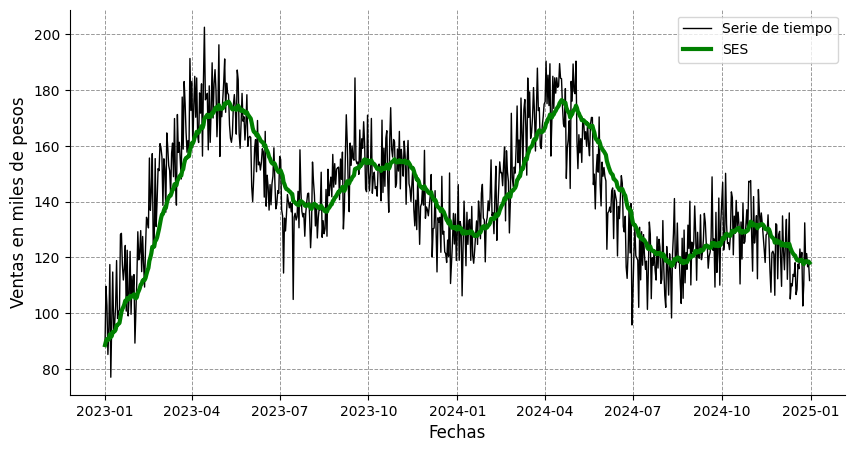

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["ventas_SES"],
    color='green',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='SES'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Los métodos basados en promedios móviles son más útiles para reducir el ruido de la serie que para predecir tendencias con precisión.

Un aspecto importante a considerar es que, al aumentar el número de datos incluidos en el promedio, se introduce un desfase temporal en la serie suavizada. En el caso de utilizar una ventana de 30 datos, ya es posible observar un ligero desplazamiento hacia la derecha.

Este desfase está directamente relacionado con el tamaño de la ventana utilizada, ya que el promedio incorpora información de varios periodos anteriores. Por lo tanto, los cambios observados en la serie suavizada pueden aparecer con cierto retraso respecto a los datos originales.

Esto no representa un problema en sí mismo, pero es fundamental tenerlo en cuenta al momento de interpretar los resultados, especialmente al identificar el momento en que ocurre un cambio en la serie.



## Tendencias no lineales

El propósito del programa es que los estudiantes aprendan el método de regresión por mínimos cuadrados, particularmente en su forma lineal, mediante la resolución de problemas donde su aplicación sea adecuada.

Sin embargo, en el contexto del análisis de series de tiempo, es poco frecuente que un modelo de regresión lineal simple represente con precisión la tendencia de los datos. En la mayoría de los casos, las tendencias presentan comportamientos más complejos que no pueden ser capturados adecuadamente por un modelo lineal.

Si bien la regresión polinomial amplía la capacidad de modelado, sigue siendo una aproximación limitada frente a la complejidad que pueden presentar las series reales. Por esta razón, resulta más apropiado considerar la tendencia como un fenómeno no lineal en términos generales.

En este sentido, el uso de regresión lineal para modelar tendencias debe entenderse como una herramienta introductoria, útil para fines didácticos, pero insuficiente para describir con precisión la gran mayoría de los comportamientos observados en la práctica.

Por eso desde "Métodos de mínimos cuadrados" vimos la regresión polinomial, que desde mi punto de vista, es la herramienta más robusta que abordamos en este curso.

Vamos a repetir el procedimiento visto en mínimos cuadrados con el fin de analizar una variable que se generó pero no se abordó en ese momento.

In [ ]:
from numpy.polynomial.polynomial import Polynomial
X = pd.to_datetime(df["fecha"]).map(pd.Timestamp.timestamp)
grado = 3
modelo = Polynomial.fit(X, y, deg = grado)
df['tendencia_polinomial'] = modelo(X)
df['ruido_polinomial'] = y - df['tendencia_polinomial']

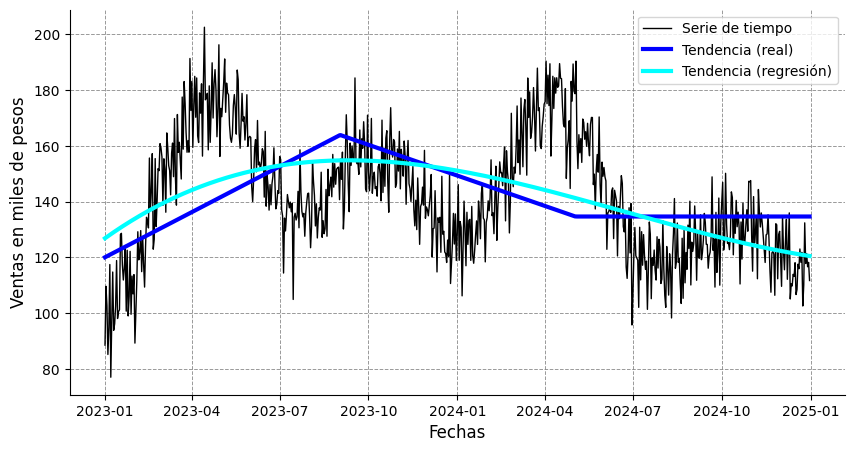

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia"],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (real)'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia_polinomial"],
    color='cyan',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (regresión)'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



En la práctica, la tendencia real de una serie de tiempo no es directamente observable, por lo que se considera una variable no accesible. Por esta razón, es necesario trabajar con aproximaciones.

En este contexto, se asumirá que la tendencia estimada mediante un modelo polinomial representa adecuadamente la tendencia de la serie. Esta no debe interpretarse como la tendencia real, sino como una aproximación obtenida a partir de los datos disponibles.

De este modo, la tendencia polinomial se utilizará como una herramienta práctica que permite describir y analizar el comportamiento general de la serie, reconociendo sus limitaciones como representación del fenómeno real.

Cuando hicimos:

```
df['ruido_polinomial'] = y - df['tendencia_polinomial']
```

Declaramos una nueva variable en el DataFrame, la variable `ruido_polinomial`que en este caso representa todo lo que no es la tendencia polinomial, es decir, la estacionalidad y el ruido. Cuando graficamos esta variable, obtenemos lo siguiente:

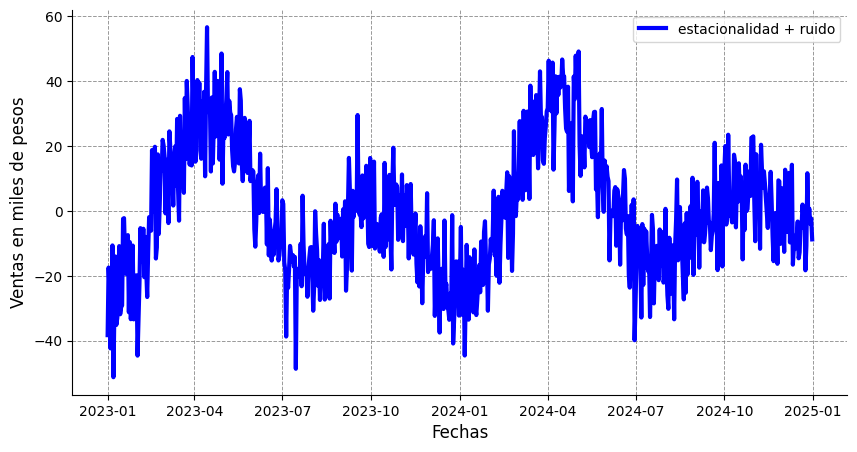

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)


# --- Gráfico de línea ---
plt.plot(
    x, df["ruido_polinomial"],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='estacionalidad + ruido'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Al centrar la serie respecto a la tendencia, el valor cero representa el nivel estimado de la tendencia polinomial. En este contexto, un valor de -40 indica que los componentes restantes, principalmente la estacionalidad y el ruido, han provocado una disminución de 40 unidades respecto a dicha tendencia.

Dado que la estacionalidad y el ruido se consideran, en general, componentes de naturaleza estacionaria, su combinación también puede tratarse como un proceso estacionario (al menos de forma aproximada). Esto permite aplicar herramientas específicas para este tipo de series.

Entre estas herramientas se encuentran las series de Fourier, las cuales permiten expresar una señal como una suma de funciones seno y coseno. Este tipo de representación es especialmente útil para modelar comportamientos periódicos, como los que caracterizan a la estacionalidad en una serie de tiempo.

Para tal efecto, es necesaria la función que se muestra a continuación:

In [ ]:
# Aquí no le muevan a nada
# Básicamente, lo que se hace este bloque es crear la función
# Transformada_de_Fourier, puesto a que no existe para lo que la quiero usar.

def Transformada_de_Fourier(serie, terminos, un_grafico):
  '''La función acepta los argumentos "serie", la cual debe de ser un array
  en numpy y en pandas de la forma df["my_variable"].values. Por otra parte,
  el parámetro "terminos" es un número natural que indica la cantidad de
  términos que desarrolla la serie. Entre mayor sea el número de términos,
  la serie será más precisa, pero más difícil de interpretar.

  La función tiene como salida una lista con los componentes sinosoidales de serie.
  El último elemento de la lista, es la suma de todos los componentes'''

  import numpy as np
  import matplotlib.pyplot as plt
  import pandas as pd
  from scipy.fftpack import fft, ifft

  # Supongamos que tienes una serie en df['AAPL_Close']
  # Reemplaza esta línea con tu DataFrame y serie específicos
  n = len(serie)

  # Calcular la transformada de Fourier
  transformada_fourier = fft(serie)

  # Obtener las frecuencias
  frecuencias = np.fft.fftfreq(n)

  # Crear un DataFrame para almacenar la frecuencia y su magnitud
  componentes = pd.DataFrame({
      'frecuencia': frecuencias,
      'magnitud': np.abs(transformada_fourier),
      'longitud_de_onda': 1 / frecuencias
  })

  # Ordenar el dataframe de mayor a menor en términos de magnitud

  componentes = componentes.sort_values(by='magnitud', ascending=False)

  # Seleccionar las frecuencias con mayor magnitud (excluyendo la frecuencia cero)
  top_frecuencias = componentes.loc[componentes['frecuencia'] > 0].nlargest(terminos, 'magnitud')
  top_frecuencias.reset_index(drop=True, inplace=True)
  print("Frecuencias principales:\n", top_frecuencias)

  # Crear el índice de tiempo para la serie
  t = np.arange(n)

  # Graficar cada componente de frecuencia junto con la serie original
  plt.figure(figsize=(12, 4))

  componente_temporal_sumado = np.zeros_like(serie)
  componentes_temporales = []

  n=0
  for i, row in top_frecuencias.iterrows():
      n+=1
      # Copiar la transformada de Fourier y mantener solo la frecuencia actual
      fourier_component = np.zeros_like(transformada_fourier)
      idx = np.where(frecuencias == row['frecuencia'])[0][0]  # índice de la frecuencia en la FFT
      fourier_component[idx] = transformada_fourier[idx]  # mantener solo la frecuencia positiva
      fourier_component[-idx] = transformada_fourier[-idx]  # mantener la frecuencia negativa correspondiente
      if n == (terminos+1):
        break

      # Reconstruir la señal en el tiempo
      componente_temporal = ifft(fourier_component).real
      componentes_temporales.append(componente_temporal)
      componente_temporal_sumado += componente_temporal

      # Graficar la componente
      plt.plot(
          componente_temporal,
          label=f'Longitud de onda {1 / row["frecuencia"]:.0f}',
          alpha=1,
          linewidth = 0.5,
          )
      plt.title('Componentes de Fourier de la Serie')
      plt.xlabel('Tiempo')
      plt.ylabel('Valor')
      plt.legend()
      plt.grid()

  componentes_temporales.append(componente_temporal_sumado)
  plt.plot(serie, label='Serie Original', color='black', alpha=0.5)
  if not un_grafico:
    plt.figure(figsize=(12, 4))
    plt.plot(serie, label='Serie Original', color='black', alpha=0.5)
  plt.plot(componente_temporal_sumado, label='Componente temporal sumada', color='red')
  plt.legend()
  plt.title('Suma de los Componentes de Fourier de la Serie')
  plt.xlabel('Tiempo')
  plt.ylabel('Valor')
  plt.grid()
  plt.show()

  return componente_temporal_sumado

No es necesario manipular el código anterior, lo que sí es importante es su ejecución. Así que, una vez que se corre el código, se puede utilizar de la siguiente manera:

/tmp/ipykernel_8206/3963029405.py:34: RuntimeWarning: divide by zero encountered in divide
  'longitud_de_onda': 1 / frecuencias


Frecuencias principales:
    frecuencia     magnitud  longitud_de_onda
0    0.005472  6784.680439        182.750000
1    0.002736  4745.856606        365.500000
2    0.004104  1009.699367        243.666667
3    0.001368   849.782757        731.000000
4    0.006840   780.003392        146.200000


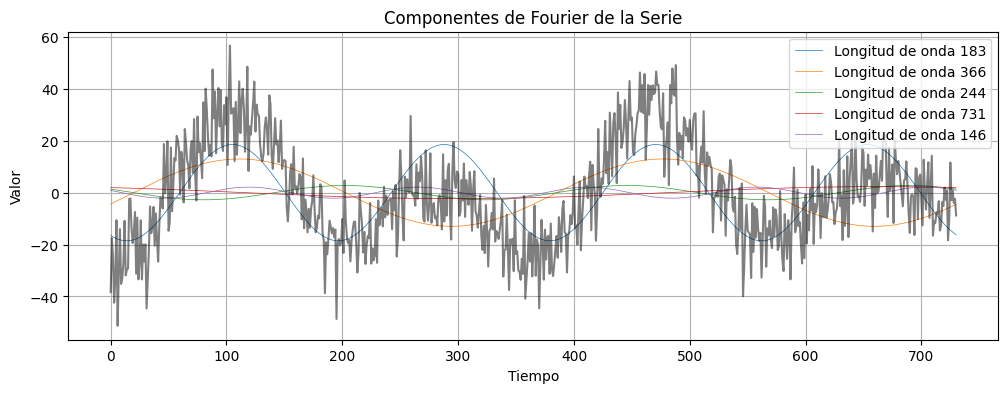

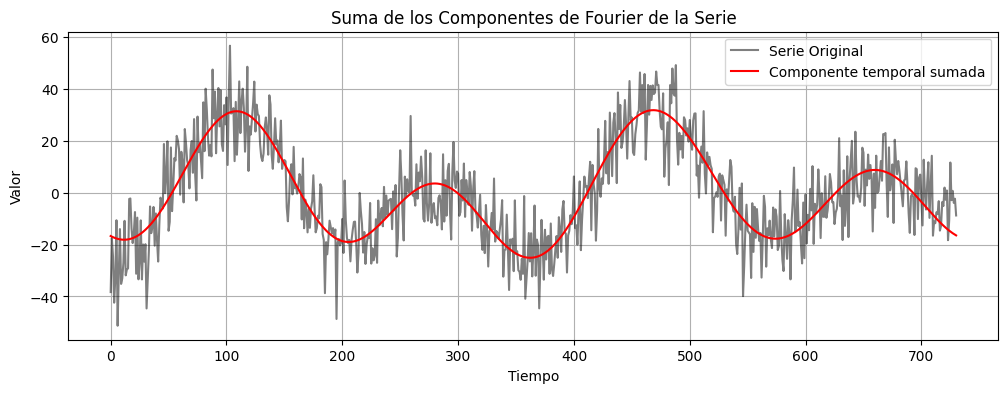

In [ ]:
serie = df['ruido_polinomial'].values
terminos = 5
un_grafico = False

cts = Transformada_de_Fourier(serie, terminos, un_grafico)
# cts: componente temporal sumado

df["estacionalidad_polinomial"] = cts

Lo longitud de onda es la distancia de cresta a cresta. En este caso, la distancia está en unidades de tiempo. Entonces cuando decimos que la longitud de onda es de 183. Decimos que el patrón se repite cada 183 días, que es justamente la mitad de un año. Entonces cada medio año se repite el mismo patrón. Y el patrón completo (el año) se tiene capturado en la variable `estacionalidad_polinomial`.

Anteriormente, el `ruido_polinomial` incluía la estacionalidad. Ahora que la conocemos, podemos extraerla y dejar sólo el ruido, por lo que ahora sí sería ruido polinomial.

```
serie_tiempo = tendencia +  estacionalidad +  ruido
```

Entonces despejando:

```
ruido = serie_tiempo - tendencia - estacionalidad
```

In [ ]:
df['ruido_polinomial'] = df['ventas'] - df['tendencia_polinomial'] - df['estacionalidad_polinomial']

## Comparación Real vs Aproximación

Ahora podemos comparar lo obtenido con análisis polinomial, y la verdad inaccesible en la práctica, pero que nosotros tenemos por ser los que crearon la serie de tiempo.

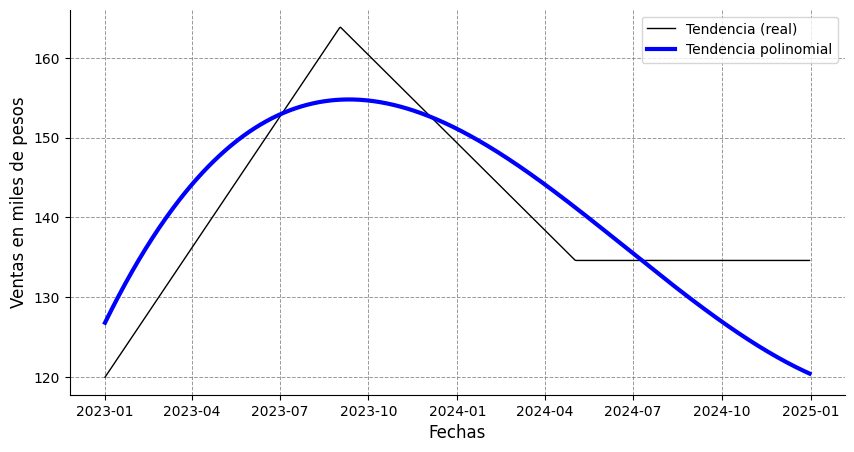

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, df['tendencia'],
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (real)'
)

# --- Gráfico de línea ---
plt.plot(
    x, df['tendencia_polinomial'],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia polinomial'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Vemos que la tendencia real y la tendencia que obtuvimos mediante regresión polinomial es muy parecida. Aunque hicimos un poco de trampa, nosotros que conociamos la tendencia real elegimos un grado 3. Quizá un analista que desconozca la tendencia real hubiera optado por un grado mayor.

Ahora analizamos la estacionalidad:

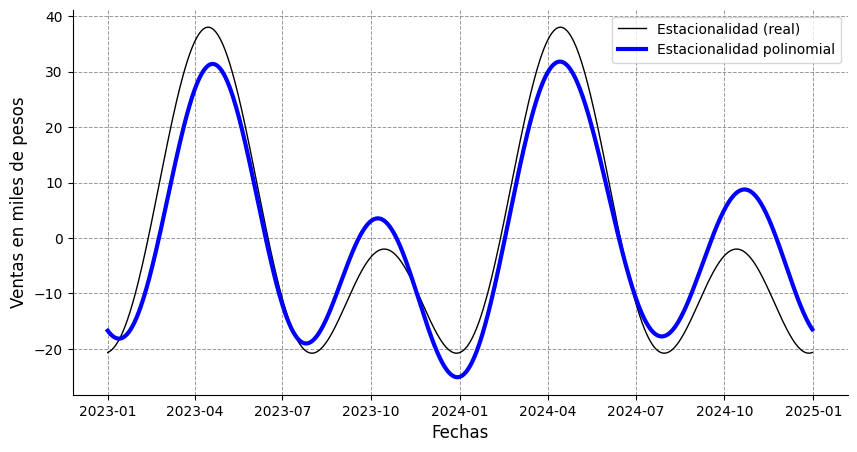

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, df['estacionalidad'],
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Estacionalidad (real)'
)

# --- Gráfico de línea ---
plt.plot(
    x, df['estacionalidad_polinomial'],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Estacionalidad polinomial'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



La estacionalidad sí es extraordinariamente similar. Las cimas y los valles se presentan en los mismos sitios.

A continuación analizamos el ruido:

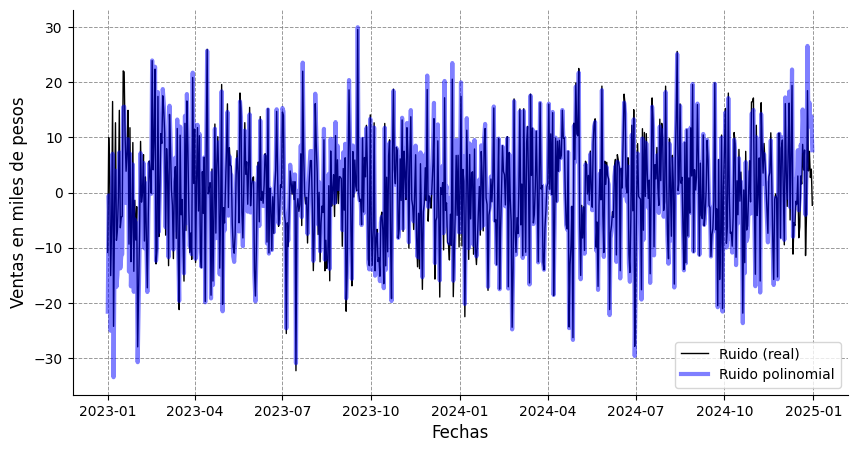

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, df['ruido'],
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Ruido (real)'
)

# --- Gráfico de línea ---
plt.plot(
    x, df['ruido_polinomial'],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Ruido polinomial',
    alpha = 0.5
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Puede surgir la idea de que el ruido, al ser un componente aleatorio, no aporta información relevante. Sin embargo, en el análisis de series de tiempo, es fundamental verificar que el ruido sea realmente aleatorio.

Al igual que los residuales en regresión lineal, el componente de ruido debe cumplir ciertas condiciones deseables: no presentar tendencia, mantener una varianza aproximadamente constante (homocedasticidad) y, en muchos contextos, seguir una distribución aproximadamente normal.

Aunque en este caso no es necesario realizar pruebas formales, estas características pueden evaluarse de manera preliminar mediante una inspección visual. Si el ruido muestra patrones, cambios en la variabilidad o comportamientos sistemáticos, esto indicaría que aún existe información estructurada que no ha sido adecuadamente modelada.

Así que llegando a este punto, no estamos revisando que los ruidos se parezcan (aunque sí se parecen) sino que sean eso, ruido.

## Análisis de los componentes de la serie

La comparación de las variables reales contra las obtenidas, es algo que sólo podemos hacer en una simulación con datos sintéticos. En la práctica profesional, este análisis es imposible. Lo que sí podemos hacer es comparar la serie real con las aproximaciones logradas:

In [ ]:
serie_real = df["ventas"]
serie_aproximada = df["tendencia_polinomial"] + df["estacionalidad_polinomial"] + df["ruido_polinomial"]

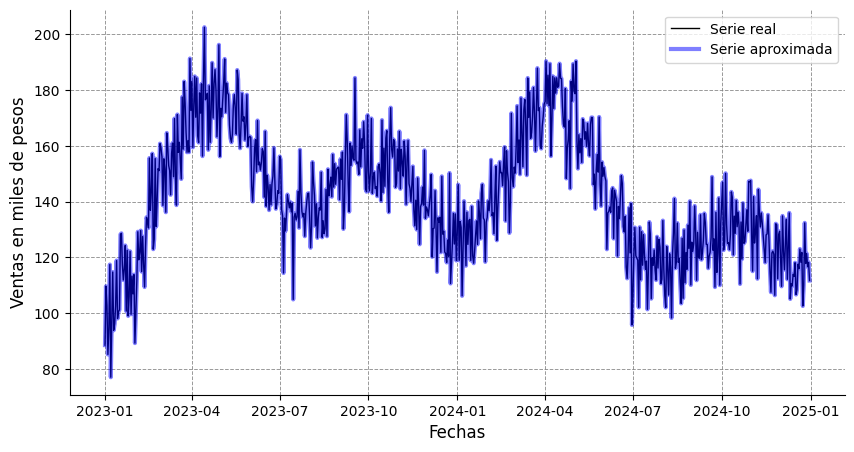

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada',
    alpha = 0.5
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



La comparación entre la serie real y la serie aproximada es mero trámite. Aunque hayamos hecho todo mal, estas dos series deben de ser idénticas. Sin embargo, hay que hacerlo para asegurarnos de que no perdimos información.

A continuación, a la serie aproximada, le quitamos el ruido.

In [ ]:
serie_real = df["ventas"]
serie_aproximada = df["tendencia_polinomial"] + df["estacionalidad_polinomial"]

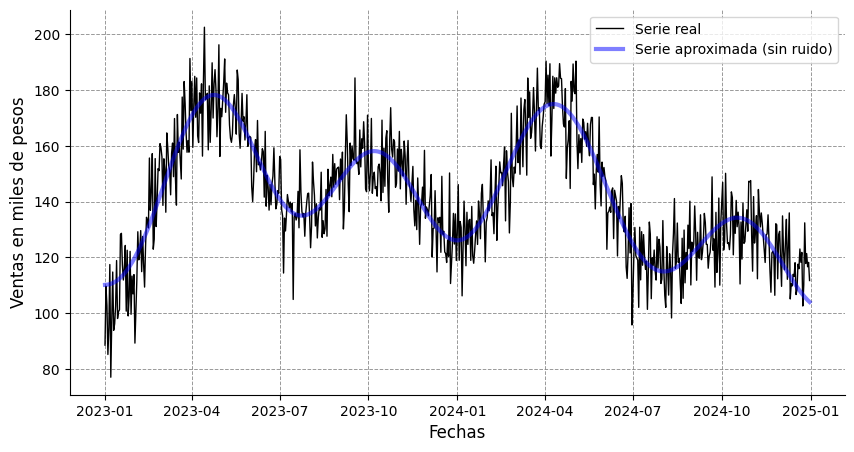

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada (sin ruido)',
    alpha = 0.5
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Se observa que la serie aproximada logra representar adecuadamente el comportamiento general de la serie de tiempo sin necesidad de incorporar el componente de ruido. Esto es un resultado favorable desde el punto de vista del análisis.

En particular, indica que la combinación de la tendencia y la estacionalidad es suficiente para capturar la mayor parte de la estructura de la serie. El ruido, por su naturaleza aleatoria, no aporta información sistemática, por lo que puede omitirse sin perder capacidad explicativa en términos generales.

Prescindir del ruido es deseable, ya que permite obtener un modelo más simple, interpretable y enfocado en los patrones relevantes de la serie.

Ahora quitamos la estacionalidad y devolvemos el ruido:

In [ ]:
serie_real = df["ventas"]
serie_aproximada = df["tendencia_polinomial"] + df["ruido_polinomial"]

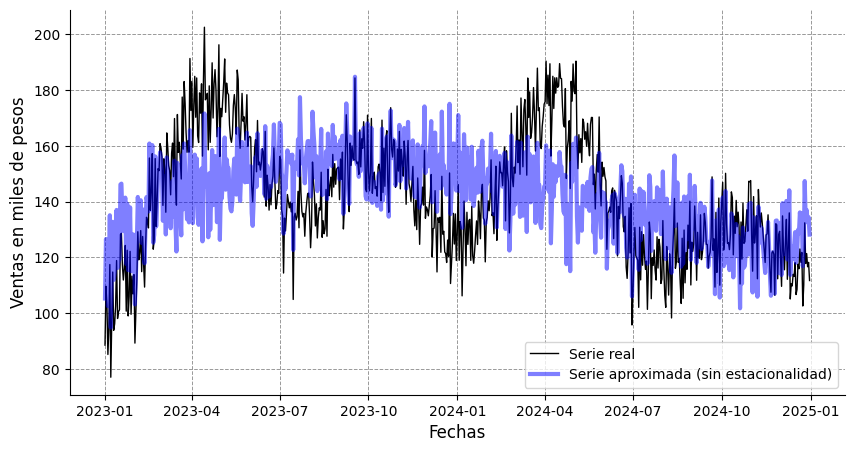

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada (sin estacionalidad)',
    alpha = 0.5
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Se observa que, al eliminar la estacionalidad, la serie resultante pierde gran parte de su forma característica y deja de parecerse a la serie original. Esto también es un resultado positivo desde el punto de vista del análisis.

En particular, indica que el componente estacional sí aporta información relevante y es fundamental para describir el comportamiento de la serie. Su ausencia genera una pérdida significativa en la capacidad de representación del modelo.

Por lo tanto, la estacionalidad puede considerarse un componente con identidad propia, cuya contribución es esencial para explicar la dinámica de la serie de tiempo.

Ahora, devolvemos la estacionalidad y quitamos la tendencia pero agregamos la media de las ventas.

In [ ]:
serie_real = df["ventas"]
serie_aproximada = df["estacionalidad_polinomial"] + df["ruido_polinomial"] + df["ventas"].mean()

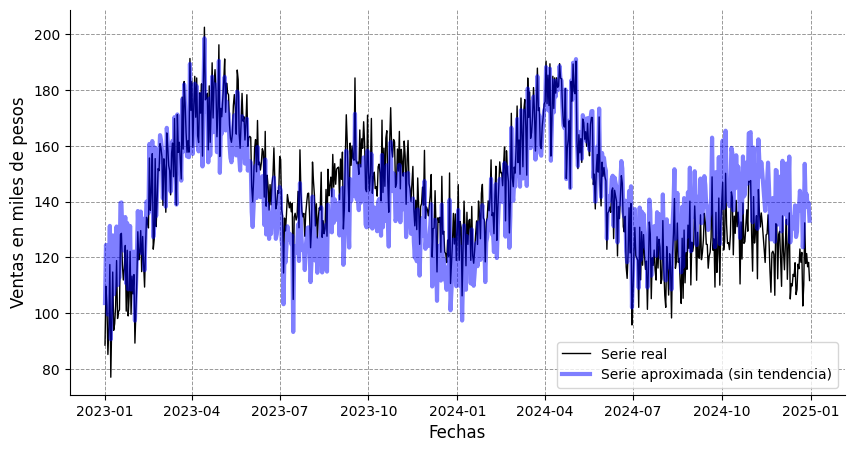

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada (sin tendencia)',
    alpha = 0.5
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Al agregar la media de la serie, se obtiene una referencia que representa un nivel constante, es decir, un comportamiento sin tendencia.

Al comparar esta nueva representación con la serie original, se observa un cambio significativo. Aunque este cambio es menor al observado cuando se eliminó la estacionalidad, sigue siendo evidente que ambas series no son equivalentes.

Esto conduce a una interpretación similar a la del caso anterior: el hecho de que exista una diferencia notable indica que el componente de tendencia sí aporta información relevante al análisis. No obstante, dado que el cambio es menos pronunciado que al eliminar la estacionalidad, se concluye que la serie está dominada por la estacionalidad, siendo este el componente con mayor influencia en su comportamiento.

Al final, tenemos el gráfico:

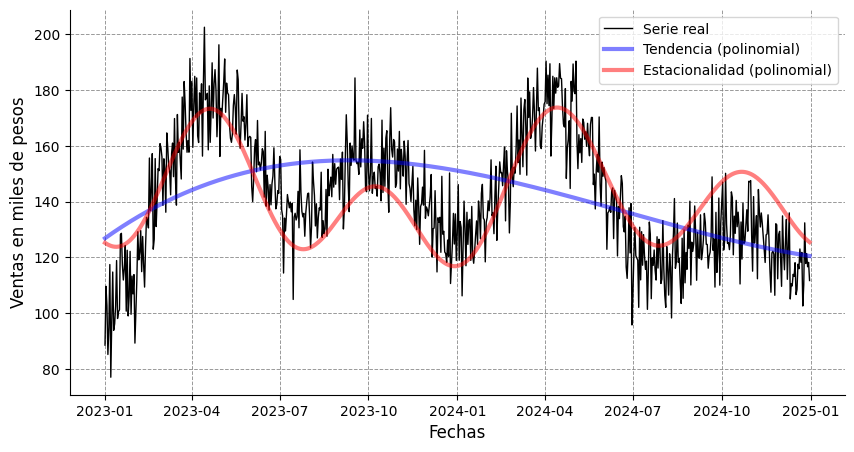

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, df["ventas"],
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia_polinomial"],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (polinomial)',
    alpha = 0.5
)

# --- Gráfico de línea ---
plt.plot(
    x, df["estacionalidad_polinomial"] + df["ventas"].mean(),
    color='red',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Estacionalidad (polinomial)',
    alpha = 0.5
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Se grafica la serie de tiempo original, junto con sus componentes principales. En particular, se presenta la tendencia de forma independiente, sin la influencia de la estacionalidad ni del ruido, con el objetivo de identificar los cambios atribuibles a este componente. De manera análoga, se grafica la estacionalidad de forma aislada, lo que permite reconocer los patrones periódicos propios de la serie.

En cuanto al ruido, su análisis se limita a verificar que sea efectivamente aleatorio. Más allá de esta comprobación, no aporta información estructurada útil para la interpretación del comportamiento de la serie.

## Alcances y limitaciones

En esta guía se propone un enfoque práctico para descomponer la serie de tiempo en sus componentes principales. En primer lugar, se estima la tendencia mediante un ajuste polinomial. Posteriormente, se analizan los residuales mediante transformadas de Fourier, con el fin de identificar los patrones periódicos dominantes, los cuales se interpretan como el componente estacional.

Finalmente, las variaciones restantes se consideran como ruido.

Es importante señalar que este procedimiento constituye una aproximación heurística, útil para fines didácticos, y no un método formal de descomposición. En la práctica, existen técnicas más robustas para este propósito; sin embargo, estas requieren un conocimiento más profundo de los conceptos involucrados.

Dado que dichos métodos no forman parte del alcance de esta unidad, he optado por proponer una estrategia que permita obtener resultados útiles sin recurrir a herramientas más complejas. De esta manera, se busca facilitar la comprensión de los componentes de una serie de tiempo dentro del nivel introductorio del curso, encontrando un equilibrio entre simplicidad y practicidad.